# Import Libraries

In [62]:
import warnings 
warnings.filterwarnings('ignore') 

import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 

# import sklearn libraries 

from sklearn.pipeline import Pipeline 

from sklearn.preprocessing import StandardScaler 

from sklearn.model_selection import cross_val_score , KFold , GridSearchCV  
from sklearn.metrics import r2_score ,mean_squared_error 

from sklearn.linear_model import LinearRegression , Ridge , Lasso 

from sklearn.tree import DecisionTreeRegressor 

from sklearn.ensemble import RandomForestRegressor ,AdaBoostRegressor , BaggingRegressor , GradientBoostingRegressor 

from sklearn.svm import SVR 

from xgboost import XGBRFRegressor 

from catboost import CatBoostRegressor 

import pickle

## lets restore or data from last `Check Point`

In [63]:
%store -r X_train 

X_train = X_train 

%store -r X_val 

X_val = X_val 

%store -r y_train 

y_train = y_train 

%store -r y_val 

y_val = y_val



In [64]:
X_train

,Year,EngineSize,Mileage,Doors,OwnerCount,Encoded_Brand,Encoded_Model,Fuel_Electric,Fuel_Hybrid,Fuel_Petrol,Transmission_Manual,Transmission_Semi-Automatic
1467,2007,2.7,246486,3,4,8931.886016,8912.797834,0.0,0.0,1.0,1.0,0.0
5768,2009,2.0,206007,4,4,8585.052045,8324.662791,0.0,0.0,0.0,0.0,1.0
5714,2016,3.1,298162,2,3,8780.323961,8818.912214,0.0,1.0,0.0,0.0,0.0
1578,2018,4.0,85467,2,4,8885.963731,8962.361011,0.0,0.0,1.0,0.0,1.0
6958,2016,3.5,249659,3,3,8780.323961,8794.280142,1.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
5226,2014,1.6,142610,5,4,8838.079903,8602.239544,0.0,0.0,1.0,0.0,1.0
5390,2006,1.2,95130,5,5,8801.433548,8995.060377,1.0,0.0,0.0,0.0,1.0
860,2013,4.5,20401,4,2,8931.886016,8912.797834,0.0,0.0,0.0,1.0,0.0
7603,2012,2.6,64095,5,2,9018.451815,9093.704453,0.0,1.0,0.0,0.0,1.0


#### here we will restore test data sets 

In [65]:
%store -r X_test 
X_test = X_test 

%store -r y_test 

y_test = y_test 

In [66]:
X_test

,Brand,Model,Year,EngineSize,Fuel,Transmission,Mileage,Doors,OwnerCount
6252,BMW,3 Series,2005,1.2,Diesel,Manual,257760,5,5
4684,Volkswagen,Golf,2013,2.9,Hybrid,Automatic,111790,5,3
1731,Toyota,RAV4,2011,5.0,Hybrid,Automatic,13473,5,4
4742,Mercedes,E-Class,2007,3.8,Diesel,Manual,133298,4,5
4521,Honda,Civic,2012,1.3,Petrol,Automatic,18611,3,5
...,...,...,...,...,...,...,...,...,...
6412,Volkswagen,Tiguan,2002,4.0,Diesel,Manual,200943,2,5
8285,Audi,A4,2017,2.9,Hybrid,Semi-Automatic,13036,4,3
7853,Volkswagen,Golf,2005,3.8,Diesel,Automatic,138757,2,1
1095,Chevrolet,Equinox,2006,3.1,Petrol,Automatic,189547,2,5


### Here we will make evalate function use it with every single function we have 


In [67]:
def evaluate_model_cross_val(X_train , y_train , X_val , y_val , model) : 
     # first make KFold cross validation 
    kf = KFold(n_splits= 5 , shuffle= True , random_state=42) 
    
    # make cross validation with metric is r2 
    cross_val_r2 = cross_val_score(model, 
                                    X_train ,
                                    y_train , 
                                    cv=kf,
                                    scoring='r2'
                                   )
    
    cross_val_rmse = -cross_val_score(model , 
                                      X_train , y_train , 
                                      cv = kf , 
                                      scoring='neg_root_mean_squared_error') 
    
    print(f'Training CV R^2 mean : {cross_val_r2.mean():.4f} ,Training CV RMSE mean : {cross_val_rmse.mean():.4f}')
    print(f'Training CV R^2 std : {cross_val_r2.std():.4f} ,Training CV RMSE std : {cross_val_rmse.std():.4f}') 
    print(cross_val_r2)
    print(cross_val_rmse)

    


In [68]:
def evaluate_model_metrics(X_train , y_train , X_val , y_val , model) : 


    # start train model in training data and evalate it by metrics

    model.fit(X_train , y_train) 
    y_train_pred = model.predict(X_train) 
    y_val_pred = model.predict(X_val) 

    r2_train = r2_score(y_train , y_train_pred) 
    rmse_train = np.sqrt(mean_squared_error( y_train , y_train_pred)) 
    
    r2_val = r2_score(y_val , y_val_pred)  
    rmse_val = np.sqrt(mean_squared_error(y_val , y_val_pred))

    print(f'training R2 : {r2_train:.4f} training rmse {rmse_train:.4f}') 
    print(f'Validation R2 : {r2_val:.4f} Vaildation rmse {rmse_val:.4f}')     





In [69]:
X_val.shape

(1600, 12)

# Model Training

### lets first build pipeline

# linear Regression

In [70]:
model = Pipeline([
    ('scaler',StandardScaler()) , 
    ('lin_reg' , LinearRegression())
])
evaluate_model_metrics(X_train=X_train , X_val=X_val , y_val=y_val , y_train=y_train , model=model)
print(10 * '*')
evaluate_model_cross_val(X_train=X_train , X_val=X_val , y_val=y_val , y_train=y_train , model=model)



training R2 : 0.9991 training rmse 95.8568
Validation R2 : 0.9996 Vaildation rmse 63.3000
**********
Training CV R^2 mean : 0.9991 ,Training CV RMSE mean : 95.2011
Training CV R^2 std : 0.0002 ,Training CV RMSE std : 12.7501
[0.99927101 0.99878916 0.99936228 0.99883808 0.99907265]
[ 85.1799364  111.28701761  78.12906457 107.83247933  93.5771216 ]


`this model isn't underfit (both CV and validation are high) and overfit (CV and validation are close to each other)`

# Ridge L2 

In [71]:
ridge_model = Pipeline([
    ('scaler' , StandardScaler()) , 
    ('ridge' , Ridge(alpha=1))
])

In [72]:
evaluate_model_cross_val(X_train=X_train , y_train= y_train , X_val= X_val , y_val=y_val , model=ridge_model) 

Training CV R^2 mean : 0.9991 ,Training CV RMSE mean : 95.2089
Training CV R^2 std : 0.0002 ,Training CV RMSE std : 12.7085
[0.9992703  0.99878965 0.99936101 0.99883905 0.99907291]
[ 85.22150637 111.26475573  78.20678982 107.78708534  93.56436023]


In [73]:
evaluate_model_metrics(X_train=X_train , y_train= y_train , X_val= X_val , y_val=y_val , model=ridge_model) 


training R2 : 0.9991 training rmse 95.8584
Validation R2 : 0.9996 Vaildation rmse 63.3846


# Lasso

In [74]:
lasso_model = Pipeline([
    ('scaler' , StandardScaler()) , 
    ('ridge' , Lasso(alpha=1))
])

In [75]:
evaluate_model_metrics(X_train=X_train , X_val=X_val , y_val=y_val , y_train=y_train , model=lasso_model)
print(10 * '*')
evaluate_model_cross_val(X_train=X_train , X_val=X_val , y_val=y_val , y_train=y_train , model=lasso_model)

training R2 : 0.9991 training rmse 95.9205
Validation R2 : 0.9996 Vaildation rmse 63.6684
**********
Training CV R^2 mean : 0.9991 ,Training CV RMSE mean : 95.2548
Training CV R^2 std : 0.0002 ,Training CV RMSE std : 12.5706
[0.99926744 0.99879136 0.99935711 0.99884199 0.99907213]
[ 85.38843792 111.18591533  78.44508029 107.6509449   93.60349329]


# Decision Tree Regressor 

In [76]:
dt_model = Pipeline([
    ('dt_reg' , DecisionTreeRegressor())
])

In [77]:
""""
    This model is overfitted

"""

'"\n    This model is overfitted\n\n'

In [78]:
evaluate_model_metrics(X_train=X_train , X_val=X_val , y_val=y_val , y_train=y_train , model=dt_model)
print(10 * '*')
evaluate_model_cross_val(X_train=X_train , X_val=X_val , y_val=y_val , y_train=y_train , model=dt_model)

training R2 : 1.0000 training rmse 0.0000
Validation R2 : 0.8969 Vaildation rmse 997.7126
**********
Training CV R^2 mean : 0.8902 ,Training CV RMSE mean : 1027.1153
Training CV R^2 std : 0.0073 ,Training CV RMSE std : 18.1579
[0.89578943 0.89995658 0.87888086 0.88904384 0.88755887]
[1004.65166344 1012.99588088 1057.29464725 1032.89332815 1027.7411164 ]


# Random Forest Regressor 

In [79]:
rf_model = Pipeline([
    ('rf_reg' , RandomForestRegressor())
])

In [80]:
evaluate_model_metrics(X_train=X_train , X_val=X_val , y_val=y_val , y_train=y_train , model=rf_model)
print(10 * '*')
evaluate_model_cross_val(X_train=X_train , X_val=X_val , y_val=y_val , y_train=y_train , model=rf_model)

training R2 : 0.9949 training rmse 224.5888
Validation R2 : 0.9623 Vaildation rmse 603.6202
**********
Training CV R^2 mean : 0.9600 ,Training CV RMSE mean : 626.9459
Training CV R^2 std : 0.0034 ,Training CV RMSE std : 20.8812
[0.96367227 0.96236694 0.95482047 0.9621217  0.95712367]
[608.40920917 620.29741073 663.14631953 606.92659464 635.94975354]


# Support Vector Regressor (SVR)

In [81]:
svr_model = Pipeline([
    ('scaler' , StandardScaler()) , 
    ('svr_reg' , SVR(kernel='rbf'))
])

In [82]:
"""
will discard this model because it's result very bad 


"""

"\nwill discard this model because it's result very bad \n\n\n"

In [83]:
evaluate_model_metrics(X_train=X_train , X_val=X_val , y_val=y_val , y_train=y_train , model=svr_model)
print(10 * '*')
evaluate_model_cross_val(X_train=X_train , X_val=X_val , y_val=y_val , y_train=y_train , model=svr_model)

training R2 : 0.0862 training rmse 2999.4412
Validation R2 : 0.0855 Vaildation rmse 2971.9019
**********
Training CV R^2 mean : 0.0685 ,Training CV RMSE mean : 3027.3353
Training CV R^2 std : 0.0003 ,Training CV RMSE std : 45.0501
[0.06804757 0.06839714 0.06852424 0.06844983 0.06899178]
[3045.60139567 3086.86304507 2985.94713869 3053.26100115 2965.00370218]


# XGboost

In [84]:
from xgboost import XGBRegressor

In [85]:
xgb_reg =Pipeline([ 
    ('scaler' , StandardScaler()) ,
    ( 'xgb' , XGBRegressor(objective='reg:squarederror'))])

In [86]:
evaluate_model_metrics(X_train=X_train , X_val=X_val , y_val=y_val , y_train=y_train , model=xgb_reg)
print(10 * '*')
evaluate_model_cross_val(X_train=X_train , X_val=X_val , y_val=y_val , y_train=y_train , model=xgb_reg)

training R2 : 0.9986 training rmse 116.9903
Validation R2 : 0.9928 Vaildation rmse 264.4133
**********


Training CV R^2 mean : 0.9920 ,Training CV RMSE mean : 280.2197
Training CV R^2 std : 0.0006 ,Training CV RMSE std : 7.3581
[0.99172628 0.99299335 0.9914276  0.99238056 0.99146771]
[286.96323918 267.70588437 286.44934792 276.13510695 283.84503701]


# CatBoost Model 

In [87]:
cat_reg =Pipeline([ 
    ( 'catboost' , CatBoostRegressor())
    ])

In [88]:
evaluate_model_metrics(X_train=X_train , X_val=X_val , y_val=y_val , y_train=y_train , model=cat_reg)
print(10 * '*')
evaluate_model_cross_val(X_train=X_train , X_val=X_val , y_val=y_val , y_train=y_train , model=cat_reg)

Learning rate set to 0.054898
0:	learn: 3012.3084247	total: 3.23ms	remaining: 3.22s
1:	learn: 2890.3325096	total: 7.67ms	remaining: 3.83s
2:	learn: 2769.7876199	total: 10.6ms	remaining: 3.51s
3:	learn: 2657.8902806	total: 13.1ms	remaining: 3.26s
4:	learn: 2555.7518582	total: 16.9ms	remaining: 3.36s
5:	learn: 2454.2454390	total: 19.4ms	remaining: 3.22s
6:	learn: 2359.7919397	total: 22.4ms	remaining: 3.18s
7:	learn: 2270.1472633	total: 24.7ms	remaining: 3.07s
8:	learn: 2184.8001772	total: 27ms	remaining: 2.97s
9:	learn: 2112.2970542	total: 29.5ms	remaining: 2.92s
10:	learn: 2036.4687881	total: 38.6ms	remaining: 3.47s
11:	learn: 1965.3883421	total: 41.5ms	remaining: 3.41s
12:	learn: 1893.7338144	total: 45.9ms	remaining: 3.49s
13:	learn: 1828.8707214	total: 48.2ms	remaining: 3.39s
14:	learn: 1769.6777389	total: 51ms	remaining: 3.35s
15:	learn: 1712.7375722	total: 53.3ms	remaining: 3.28s
16:	learn: 1656.7610150	total: 55.9ms	remaining: 3.23s
17:	learn: 1597.9054323	total: 58.3ms	remaining: 

# AdaBoost 

In [89]:
adaboost_reg =Pipeline([ 
    ( 'catboost' , AdaBoostRegressor())
    ])

In [90]:
evaluate_model_metrics(X_train=X_train , X_val=X_val , y_val=y_val , y_train=y_train , model=adaboost_reg)
print(10 * '*')
evaluate_model_cross_val(X_train=X_train , X_val=X_val , y_val=y_val , y_train=y_train , model=adaboost_reg)

training R2 : 0.8910 training rmse 1035.8254
Validation R2 : 0.8835 Vaildation rmse 1060.7691
**********
Training CV R^2 mean : 0.8874 ,Training CV RMSE mean : 1053.1442
Training CV R^2 std : 0.0045 ,Training CV RMSE std : 13.5108
[0.89312668 0.89051247 0.88010551 0.88806776 0.88525342]
[1042.79589133 1059.78954011 1060.60280981 1069.95819099 1032.57448566]


# Model Selection 

Based on this results of default model traing , the best model  is `CatBoost`  with R^2 0.9997 and RMSE 50 $🏆

In [91]:
best_model = CatBoostRegressor() 

In [92]:
evaluate_model_metrics(X_train=X_train , X_val=X_val , y_train=y_train , y_val = y_val , model=best_model)

Learning rate set to 0.054898
0:	learn: 3012.3084247	total: 2ms	remaining: 2s
1:	learn: 2890.3325096	total: 3.94ms	remaining: 1.97s
2:	learn: 2769.7876199	total: 5.79ms	remaining: 1.92s
3:	learn: 2657.8902806	total: 7.63ms	remaining: 1.9s
4:	learn: 2555.7518582	total: 9.78ms	remaining: 1.95s
5:	learn: 2454.2454390	total: 11.6ms	remaining: 1.93s
6:	learn: 2359.7919397	total: 13.2ms	remaining: 1.88s
7:	learn: 2270.1472633	total: 14.9ms	remaining: 1.85s
8:	learn: 2184.8001772	total: 16.6ms	remaining: 1.82s
9:	learn: 2112.2970542	total: 18.4ms	remaining: 1.82s
10:	learn: 2036.4687881	total: 20.5ms	remaining: 1.84s
11:	learn: 1965.3883421	total: 22.2ms	remaining: 1.83s
12:	learn: 1893.7338144	total: 23.9ms	remaining: 1.81s
13:	learn: 1828.8707214	total: 25.6ms	remaining: 1.8s
14:	learn: 1769.6777389	total: 27.2ms	remaining: 1.79s
15:	learn: 1712.7375722	total: 28.8ms	remaining: 1.77s
16:	learn: 1656.7610150	total: 30.4ms	remaining: 1.76s
17:	learn: 1597.9054323	total: 32.1ms	remaining: 1.75

# Tuning Model with Hyper paramter 

in this section will import performance of model 

In [93]:
params_grid = {
    'iterations' : [100 , 200] , 
    'learning_rate' : [0.01 , 0.05 , 0.1 , 1 ] , 
    'depth' : [4 , 6 , 8] , 
    'l2_leaf_reg' : [1 , 2 ,3] , 
    'border_count' :[32 , 64 , 128] 
}

In [94]:
# instantiaten model 
grid_search = GridSearchCV(estimator=best_model ,
                           param_grid=params_grid , 
                           cv = 5 , 
                           scoring='neg_root_mean_squared_error' , 
                           n_jobs= -1 , 
                           verbose=2)

In [95]:
grid_search.fit(X_train , y_train)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
0:	learn: 1676.4791434	total: 1.35ms	remaining: 270ms
1:	learn: 1333.8927113	total: 2.66ms	remaining: 264ms
2:	learn: 1062.1139933	total: 3.95ms	remaining: 259ms
3:	learn: 803.3245446	total: 5.27ms	remaining: 258ms
4:	learn: 670.9133151	total: 6.63ms	remaining: 258ms
5:	learn: 572.4532224	total: 8.06ms	remaining: 261ms
6:	learn: 525.4684448	total: 9.4ms	remaining: 259ms
7:	learn: 492.1113547	total: 11.5ms	remaining: 275ms
8:	learn: 433.8008859	total: 12.7ms	remaining: 269ms
9:	learn: 404.2375336	total: 14ms	remaining: 266ms
10:	learn: 376.7036999	total: 15.3ms	remaining: 262ms
11:	learn: 356.5395021	total: 16.7ms	remaining: 262ms
12:	learn: 337.1043538	total: 18.1ms	remaining: 261ms
13:	learn: 322.5802598	total: 19.4ms	remaining: 258ms
14:	learn: 298.3056440	total: 20.7ms	remaining: 255ms
15:	learn: 284.1148959	total: 21.9ms	remaining: 252ms
16:	learn: 269.2883052	total: 23.5ms	remaining: 253ms
17:	learn: 259.5089411	total

GridSearchCV(cv=5,
             estimator=<catboost.core.CatBoostRegressor object at 0x0000027FD54914C0>,
             n_jobs=-1,
             param_grid={'border_count': [32, 64, 128], 'depth': [4, 6, 8],
                         'iterations': [100, 200], 'l2_leaf_reg': [1, 2, 3],
                         'learning_rate': [0.01, 0.05, 0.1, 1]},
             scoring='neg_root_mean_squared_error', verbose=2)

#### the best paramters to train this model after tuning 

In [96]:
print(f'best paramter is {grid_search.best_params_}')

best paramter is {'border_count': 128, 'depth': 4, 'iterations': 200, 'l2_leaf_reg': 2, 'learning_rate': 1}


In [97]:
best_model_tuned = grid_search.best_estimator_

In [98]:
evaluate_model_metrics(X_train=X_train , y_train=y_train , y_val=y_val , X_val=X_val , model=best_model_tuned)

0:	learn: 1676.4791434	total: 1.46ms	remaining: 291ms
1:	learn: 1333.8927113	total: 2.75ms	remaining: 272ms
2:	learn: 1062.1139933	total: 4.46ms	remaining: 293ms
3:	learn: 803.3245446	total: 5.75ms	remaining: 282ms
4:	learn: 670.9133151	total: 7.11ms	remaining: 277ms
5:	learn: 572.4532224	total: 8.69ms	remaining: 281ms
6:	learn: 525.4684448	total: 10.5ms	remaining: 290ms
7:	learn: 492.1113547	total: 12ms	remaining: 287ms
8:	learn: 433.8008859	total: 13.5ms	remaining: 287ms
9:	learn: 404.2375336	total: 14.9ms	remaining: 283ms
10:	learn: 376.7036999	total: 16.2ms	remaining: 279ms
11:	learn: 356.5395021	total: 17.5ms	remaining: 274ms
12:	learn: 337.1043538	total: 18.7ms	remaining: 269ms
13:	learn: 322.5802598	total: 20ms	remaining: 265ms
14:	learn: 298.3056440	total: 21.3ms	remaining: 262ms
15:	learn: 284.1148959	total: 22.6ms	remaining: 260ms
16:	learn: 269.2883052	total: 23.9ms	remaining: 258ms
17:	learn: 259.5089411	total: 25.1ms	remaining: 254ms
18:	learn: 248.4391626	total: 26.7ms	re

### this result mean the model before tuned is better than after tune 

In [99]:
# then the final model is best model

final_model = best_model

In [100]:
final_model.fit(X_train , y_train) 
y_train_pred = final_model.predict(X_train) 
y_val_pred = final_model.predict(X_val) 

r2_train = r2_score(y_train , y_train_pred) 
rmse_train = np.sqrt(mean_squared_error( y_train , y_train_pred)) 
    
r2_val = r2_score(y_val , y_val_pred)  
rmse_val = np.sqrt(mean_squared_error(y_val , y_val_pred))

print(f'training R2 : {r2_train:.4f} training rmse {rmse_train:.4f}') 
print(f'Validation R2 : {r2_val:.4f} Vaildation rmse {rmse_val:.4f}')     


Learning rate set to 0.054898
0:	learn: 3012.3084247	total: 1.9ms	remaining: 1.9s
1:	learn: 2890.3325096	total: 3.57ms	remaining: 1.78s
2:	learn: 2769.7876199	total: 5.56ms	remaining: 1.85s
3:	learn: 2657.8902806	total: 8.12ms	remaining: 2.02s
4:	learn: 2555.7518582	total: 10.1ms	remaining: 2s
5:	learn: 2454.2454390	total: 11.8ms	remaining: 1.95s
6:	learn: 2359.7919397	total: 13.5ms	remaining: 1.92s
7:	learn: 2270.1472633	total: 15.1ms	remaining: 1.88s
8:	learn: 2184.8001772	total: 16.8ms	remaining: 1.85s
9:	learn: 2112.2970542	total: 18.6ms	remaining: 1.84s
10:	learn: 2036.4687881	total: 20.3ms	remaining: 1.83s
11:	learn: 1965.3883421	total: 22.2ms	remaining: 1.83s
12:	learn: 1893.7338144	total: 24.4ms	remaining: 1.85s
13:	learn: 1828.8707214	total: 26.4ms	remaining: 1.86s
14:	learn: 1769.6777389	total: 34.7ms	remaining: 2.28s
15:	learn: 1712.7375722	total: 37.3ms	remaining: 2.29s
16:	learn: 1656.7610150	total: 41.2ms	remaining: 2.38s
17:	learn: 1597.9054323	total: 43.6ms	remaining: 2

# Now will evaluation model 

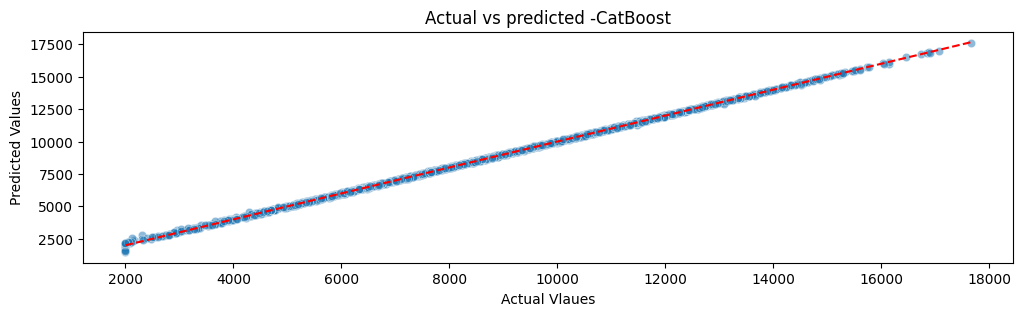

In [101]:
plt.figure(figsize = (12 , 3)) 

sns.scatterplot(x= y_val , 
                y= y_val_pred , 
                alpha = 0.5) 

plt.plot([min(y_val) , max(y_val)] , [min(y_val) , max(y_val)] , linestyle='--' , color = 'red') 

plt.xlabel('Actual Vlaues') 
plt.ylabel('Predicted Values') 
plt.title('Actual vs predicted -CatBoost') 

plt.show()

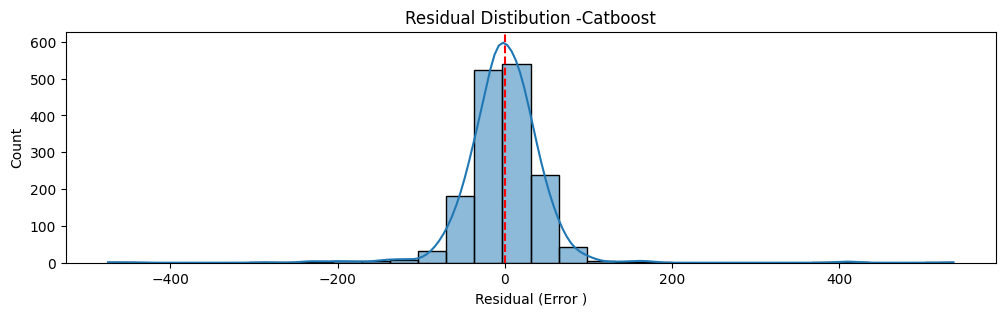

In [102]:
# Residul Plot (Error ) 

residual =y_val - y_val_pred 

plt.figure(figsize=(12 , 3)) 

sns.histplot(residual , 
             bins= 30 , 
             kde=True) 
plt.axvline(0 , color = 'red' , linestyle = 'dashed') 

plt.xlabel("Residual (Error )") 

plt.title("Residual Distibution -Catboost") 

plt.show()

# Apply Model on test data

#### load encoders 

In [103]:
X_train.columns.to_list()

['Year',
 'EngineSize',
 'Mileage',
 'Doors',
 'OwnerCount',
 'Encoded_Brand',
 'Encoded_Model',
 'Fuel_Electric',
 'Fuel_Hybrid',
 'Fuel_Petrol',
 'Transmission_Manual',
 'Transmission_Semi-Automatic']

In [104]:
with open('../../models/Brand_Encoder.pkl' , 'rb') as f : 
    brand_encoder = pickle.load(f) # brand encoder 

with open('../../models/Model_Encoder.pkl' , 'rb') as f : 
    model_encoder = pickle.load(f)    # Model encoder 


with open('../../models/OHE_Encoder.pkl' , 'rb') as f : 
    ohe_encoder = pickle.load(f) # Fule and Transmission

In [105]:
X_test['Encoded_Brand'] = X_test['Brand'].map(brand_encoder)

In [106]:
X_test['Encoded_Model'] = X_test['Model'].map(model_encoder) 

In [107]:
X_test

,Brand,Model,Year,EngineSize,Fuel,Transmission,Mileage,Doors,OwnerCount,Encoded_Brand,Encoded_Model
6252,BMW,3 Series,2005,1.2,Diesel,Manual,257760,5,5,8650.208122,8854.695971
4684,Volkswagen,Golf,2013,2.9,Hybrid,Automatic,111790,5,3,8901.128019,8782.205323
1731,Toyota,RAV4,2011,5.0,Hybrid,Automatic,13473,5,4,8801.433548,8633.622047
4742,Mercedes,E-Class,2007,3.8,Diesel,Manual,133298,4,5,8892.547554,8934.714859
4521,Honda,Civic,2012,1.3,Petrol,Automatic,18611,3,5,8585.052045,8324.662791
...,...,...,...,...,...,...,...,...,...,...,...
6412,Volkswagen,Tiguan,2002,4.0,Diesel,Manual,200943,2,5,8901.128019,9146.532423
8285,Audi,A4,2017,2.9,Hybrid,Semi-Automatic,13036,4,3,8931.886016,8854.704861
7853,Volkswagen,Golf,2005,3.8,Diesel,Automatic,138757,2,1,8901.128019,8782.205323
1095,Chevrolet,Equinox,2006,3.1,Petrol,Automatic,189547,2,5,9018.451815,9093.704453


In [108]:

X_test

,Brand,Model,Year,EngineSize,Fuel,Transmission,Mileage,Doors,OwnerCount,Encoded_Brand,Encoded_Model
6252,BMW,3 Series,2005,1.2,Diesel,Manual,257760,5,5,8650.208122,8854.695971
4684,Volkswagen,Golf,2013,2.9,Hybrid,Automatic,111790,5,3,8901.128019,8782.205323
1731,Toyota,RAV4,2011,5.0,Hybrid,Automatic,13473,5,4,8801.433548,8633.622047
4742,Mercedes,E-Class,2007,3.8,Diesel,Manual,133298,4,5,8892.547554,8934.714859
4521,Honda,Civic,2012,1.3,Petrol,Automatic,18611,3,5,8585.052045,8324.662791
...,...,...,...,...,...,...,...,...,...,...,...
6412,Volkswagen,Tiguan,2002,4.0,Diesel,Manual,200943,2,5,8901.128019,9146.532423
8285,Audi,A4,2017,2.9,Hybrid,Semi-Automatic,13036,4,3,8931.886016,8854.704861
7853,Volkswagen,Golf,2005,3.8,Diesel,Automatic,138757,2,1,8901.128019,8782.205323
1095,Chevrolet,Equinox,2006,3.1,Petrol,Automatic,189547,2,5,9018.451815,9093.704453


#### check nulls in encoded data

In [109]:
X_test[['Encoded_Brand' , 'Encoded_Model']].isna().sum()

Encoded_Brand    0
Encoded_Model    0
dtype: int64

#### drop Brand and model columns 

In [110]:
X_test.drop(['Model' , 'Brand'] , axis= 1 , inplace=True)

### make One Hot encoding for transmation and fule 

In [111]:
X_test.columns.to_list()

['Year',
 'EngineSize',
 'Fuel',
 'Transmission',
 'Mileage',
 'Doors',
 'OwnerCount',
 'Encoded_Brand',
 'Encoded_Model']

In [112]:
categorical_column = ['Fuel' , 'Transmission']

In [113]:
encode_array_list = ohe_encoder.transform(X_test[categorical_column])

In [114]:
encoded_df_test = pd.DataFrame(encode_array_list , columns=ohe_encoder.get_feature_names_out(categorical_column))

In [115]:
X_test_encoded = X_test.drop(categorical_column , axis= 1 ).reset_index(drop = True)

In [116]:
X_test = pd.concat([X_test_encoded , encoded_df_test] , axis = 1)

In [117]:
X_test

,Year,EngineSize,Mileage,Doors,OwnerCount,Encoded_Brand,Encoded_Model,Fuel_Electric,Fuel_Hybrid,Fuel_Petrol,Transmission_Manual,Transmission_Semi-Automatic
0,2005,1.2,257760,5,5,8650.208122,8854.695971,0.0,0.0,0.0,1.0,0.0
1,2013,2.9,111790,5,3,8901.128019,8782.205323,0.0,1.0,0.0,0.0,0.0
2,2011,5.0,13473,5,4,8801.433548,8633.622047,0.0,1.0,0.0,0.0,0.0
3,2007,3.8,133298,4,5,8892.547554,8934.714859,0.0,0.0,0.0,1.0,0.0
4,2012,1.3,18611,3,5,8585.052045,8324.662791,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1995,2002,4.0,200943,2,5,8901.128019,9146.532423,0.0,0.0,0.0,1.0,0.0
1996,2017,2.9,13036,4,3,8931.886016,8854.704861,0.0,1.0,0.0,0.0,1.0
1997,2005,3.8,138757,2,1,8901.128019,8782.205323,0.0,0.0,0.0,0.0,0.0
1998,2006,3.1,189547,2,5,9018.451815,9093.704453,0.0,0.0,1.0,0.0,0.0


In [118]:
X_test.isna().sum()

Year                           0
EngineSize                     0
Mileage                        0
Doors                          0
OwnerCount                     0
Encoded_Brand                  0
Encoded_Model                  0
Fuel_Electric                  0
Fuel_Hybrid                    0
Fuel_Petrol                    0
Transmission_Manual            0
Transmission_Semi-Automatic    0
dtype: int64

### Now I can Predict Result

In [119]:
y_test_pred = final_model.predict(X_test)

In [120]:
r2_test = r2_score(y_test  ,  y_test_pred) 
rmse_test = np.sqrt(mean_squared_error(y_test , y_test_pred)) 

print(f'R2 test is {r2_test:.4f} and the RMSE is {rmse_test}')


R2 test is 0.9997 and the RMSE is 48.9199437708115


# This result is powerfull good becasue this is fully unseen data and that mean model able to generalized unseen data

# CheckPoint

#### save Final model

In [123]:
pickle.dump(final_model , open('../../models/Model.pkl' , 'wb'))